# Notebook 02 — Expressibility Analysis

**Project:** Quantum Attention Mechanism Benchmark  
**Author:** Sarah Assou  
**Goal:** Measure and compare the *expressibility* of the three VQC architectures from Notebook 01.

---

## What this notebook covers

1. **What is expressibility?** — theory and intuition
2. **The Sim et al. (2019) metric** — how to compute it
3. **Computing expressibility** for SEL, IQP, and HEA
4. **Expressibility vs. circuit depth** — how it changes as we add layers
5. **Results & interpretation** — which circuit is best for attention?

---

> 📖 **Reference:** Sim, S., Johnson, P. D., & Aspuru-Guzik, A. (2019).  
> *Expressibility and Entangling Capability of Parameterized Quantum Circuits for Hybrid Quantum-Classical Algorithms.*  
> Advanced Quantum Technologies, 2(12), 1900070. https://arxiv.org/abs/1905.10876

---

## Theory: What is Expressibility?

### Intuition

Imagine you want a circuit to produce attention weights for many different inputs. A circuit is **expressive** if it can generate a *wide variety* of output states — covering the space of all possible quantum states (the Hilbert space) as uniformly as possible.

A circuit with **low expressibility** always outputs states in a small, restricted region of Hilbert space — like a paintbrush that can only paint one corner of the canvas. No matter what parameters you choose, the outputs are always similar.

A circuit with **high expressibility** can reach almost any point in Hilbert space — like a paintbrush that can cover the whole canvas.

### The Sim et al. (2019) Metric — Formal Definition

The expressibility $\mathcal{E}$ of a parameterized circuit $U(\theta)$ is defined as the **KL divergence** between:
- The distribution of **fidelities** generated by the circuit with random parameters
- The distribution of fidelities for a **Haar-random** unitary (the theoretically most expressive possible)

$$\mathcal{E} = D_{KL}\left( \hat{P}_{PQC}(F; \theta) \| P_{Haar}(F) \right)$$

Where **fidelity** between two quantum states $|\psi_1\rangle$ and $|\psi_2\rangle$ is:
$$F = |\langle \psi_1 | \psi_2 \rangle|^2 \in [0, 1]$$

### Key insight:
- **Lower $\mathcal{E}$** = circuit is **more expressive** (closer to Haar-random)
- **Higher $\mathcal{E}$** = circuit is **less expressive** (restricted to a small region)

### The Haar distribution (reference)

For an $n$-qubit system, the fidelity distribution of Haar-random states follows:

$$P_{Haar}(F) = (N-1)(1-F)^{N-2}, \quad N = 2^n$$

This is a *Beta distribution* skewed heavily toward $F=0$ — meaning truly random quantum states are almost always orthogonal to each other.

---

## Cell 1 — Setup (Run First)

In [1]:
!pip install pennylane pennylane-lightning matplotlib numpy scipy torch --quiet
print("✅ Packages ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.9 MB/s eta 0:00:00
✅ Packages ready.


In [2]:
import pennylane as qml
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import entropy
from scipy.special import comb

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

# ── Global configuration ────────────────────────────────────────────────────
N_QUBITS   = 4      # Keep same as Notebook 01
N_LAYERS   = 2      # Baseline
N_SAMPLES  = 2000   # Number of random state pairs for expressibility (higher = more accurate)
N_BINS     = 75     # Histogram bins for fidelity distribution
MAX_LAYERS = 6      # For the depth sweep experiment

dev = qml.device("lightning.qubit", wires=N_QUBITS)
N   = 2 ** N_QUBITS  # Hilbert space dimension

print(f"Configuration : {N_QUBITS} qubits, N={N}, {N_SAMPLES} sample pairs")
print(f"Depth sweep   : 1 to {MAX_LAYERS} layers")
print(f"✅ Setup complete.")

Configuration : 4 qubits, N=16, 2000 sample pairs
Depth sweep   : 1 to 6 layers
✅ Setup complete.


---

## Cell 2 — Redefine the Three Circuits

We redefine the circuits here so this notebook is self-contained (no need to re-run Notebook 01). They are identical to the definitions there.

In [3]:
# ── Circuit definitions (statevector mode for expressibility) ───────────────
# We use qml.state() instead of expval to get the full quantum state vector
# This is needed to compute fidelity: F = |<psi1|psi2>|^2

dev_sv = qml.device("lightning.qubit", wires=N_QUBITS)

@qml.qnode(dev_sv)
def sel_statevector(inputs, weights):
    """SEL circuit returning full statevector."""
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return qml.state()


@qml.qnode(dev_sv)
def iqp_statevector(inputs, weights):
    """IQP circuit with data re-uploading, returning full statevector."""
    for layer in range(weights.shape[0]):
        for i in range(N_QUBITS):
            qml.RX(inputs[i], wires=i)
            qml.RZ(weights[layer, i, 0], wires=i)
        for i in range(N_QUBITS):
            qml.IsingZZ(weights[layer, i, 1], wires=[i, (i+1) % N_QUBITS])
        for i in range(N_QUBITS):
            qml.Hadamard(wires=i)
    return qml.state()


@qml.qnode(dev_sv)
def hea_statevector(inputs, weights):
    """HEA circuit returning full statevector."""
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    for layer in range(weights.shape[0]):
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i+1])
    return qml.state()


# Quick test: statevectors should have norm = 1
test_inp = np.random.uniform(0, np.pi, N_QUBITS)
test_w2  = np.random.uniform(0, 2*np.pi, (N_LAYERS, N_QUBITS, 2))
test_wSEL = np.random.uniform(0, 2*np.pi, qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS))

sv_sel = sel_statevector(test_inp, test_wSEL)
sv_iqp = iqp_statevector(test_inp, test_w2)
sv_hea = hea_statevector(test_inp, test_w2)

print(f"SEL statevector norm : {np.abs(sv_sel @ sv_sel.conj()):.6f} (should be 1.0)")
print(f"IQP statevector norm : {np.abs(sv_iqp @ sv_iqp.conj()):.6f} (should be 1.0)")
print(f"HEA statevector norm : {np.abs(sv_hea @ sv_hea.conj()):.6f} (should be 1.0)")
print("✅ All circuits verified.")

SEL statevector norm : 1.000000 (should be 1.0)
IQP statevector norm : 1.000000 (should be 1.0)
HEA statevector norm : 1.000000 (should be 1.0)
✅ All circuits verified.


---

## Cell 3 — Core Functions: Fidelity, Haar Distribution, KL Divergence

These are the three building blocks of the Sim et al. metric.

In [4]:
# ── Core expressibility functions ───────────────────────────────────────────

def compute_fidelity(state1, state2):
    """
    Compute fidelity between two pure quantum states.
    F = |<psi1|psi2>|^2

    Args:
        state1, state2: complex numpy arrays of shape (N,) — statevectors
    Returns:
        float in [0, 1]
    """
    inner_product = np.dot(state1.conj(), state2)
    return float(np.abs(inner_product) ** 2)


def haar_fidelity_distribution(n_qubits, n_bins=N_BINS):
    """
    Compute the theoretical Haar-random fidelity distribution.

    For an n-qubit system (dimension N = 2^n):
        P_Haar(F) = (N-1) * (1-F)^(N-2)

    This is the REFERENCE distribution — what a maximally expressive
    circuit would look like.

    Returns:
        bin_centers : array of fidelity values
        haar_probs  : normalized probability for each bin
    """
    N = 2 ** n_qubits
    bin_edges   = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    # P_Haar(F) = (N-1)(1-F)^(N-2)
    haar_probs = (N - 1) * (1 - bin_centers) ** (N - 2) * bin_width
    haar_probs /= haar_probs.sum()  # Normalize to probability distribution

    return bin_centers, haar_probs


def compute_expressibility(circuit_fn, weight_shape, n_qubits, n_samples=N_SAMPLES, n_bins=N_BINS):
    """
    Compute the expressibility of a parameterized circuit.

    Steps:
    1. Sample n_samples pairs of random parameters (theta1, theta2)
    2. Run the circuit with each pair to get statevectors |psi1>, |psi2>
    3. Compute fidelity F = |<psi1|psi2>|^2 for each pair
    4. Build histogram of fidelities -> empirical distribution P_PQC
    5. Compare to Haar distribution P_Haar using KL divergence

    Args:
        circuit_fn   : function(inputs, weights) -> statevector
        weight_shape : tuple — shape of the weight array
        n_qubits     : int
        n_samples    : int — number of random parameter pairs
        n_bins       : int — histogram resolution

    Returns:
        expressibility  : float (lower = more expressive)
        fidelities      : array of sampled fidelity values
        pqc_probs       : empirical fidelity distribution
        haar_probs      : Haar reference distribution
        bin_centers     : fidelity bin centers
    """
    fidelities = []

    # Fixed input (expressibility is measured over parameter space, not input space)
    fixed_input = np.zeros(n_qubits)  # Use zero input for cleaner parameter-space analysis

    for _ in range(n_samples):
        # Sample two independent random parameter sets
        theta1 = np.random.uniform(0, 2*np.pi, weight_shape)
        theta2 = np.random.uniform(0, 2*np.pi, weight_shape)

        # Get statevectors
        psi1 = np.array(circuit_fn(fixed_input, theta1))
        psi2 = np.array(circuit_fn(fixed_input, theta2))

        # Compute fidelity
        F = compute_fidelity(psi1, psi2)
        fidelities.append(F)

    fidelities = np.array(fidelities)

    # Build empirical histogram
    bin_edges   = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    counts, _ = np.histogram(fidelities, bins=bin_edges)
    pqc_probs = counts / counts.sum()

    # Haar reference distribution
    _, haar_probs = haar_fidelity_distribution(n_qubits, n_bins)

    # KL divergence: add small epsilon to avoid log(0)
    epsilon = 1e-10
    expr = entropy(pqc_probs + epsilon, haar_probs + epsilon)

    return expr, fidelities, pqc_probs, haar_probs, bin_centers


print("✅ Core functions defined.")
print()
print("Quick Haar distribution check:")
centers, haar = haar_fidelity_distribution(N_QUBITS)
print(f"  Haar peak at F ≈ {centers[np.argmax(haar)]:.3f} (expected near 0 for {N_QUBITS} qubits)")
print(f"  Haar sum       = {haar.sum():.6f} (should be 1.0)")

✅ Core functions defined.

Quick Haar distribution check:
  Haar peak at F ≈ 0.007 (expected near 0 for 4 qubits)
  Haar sum       = 1.000000 (should be 1.0)


---

## Cell 4 — Compute Expressibility for All Three Circuits

**This cell takes 3–5 minutes.** *It runs 2000 circuit evaluations per architecture (6000 total).*

In [5]:
import time

sel_weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=N_QUBITS)
iqp_weight_shape = (N_LAYERS, N_QUBITS, 2)
hea_weight_shape = (N_LAYERS, N_QUBITS, 2)

results = {}

for name, circuit, shape in [
    ("SEL", sel_statevector, sel_weight_shape),
    ("IQP", iqp_statevector, iqp_weight_shape),
    ("HEA", hea_statevector, hea_weight_shape)
]:
    print(f"Computing expressibility for {name}...", end=" ", flush=True)
    t0 = time.time()

    expr, fids, pqc_probs, haar_probs, bin_centers = compute_expressibility(
        circuit, shape, N_QUBITS, n_samples=N_SAMPLES
    )

    elapsed = time.time() - t0
    results[name] = {
        'expressibility': expr,
        'fidelities':     fids,
        'pqc_probs':      pqc_probs,
        'haar_probs':     haar_probs,
        'bin_centers':    bin_centers
    }
    print(f"done in {elapsed:.1f}s  |  Expressibility = {expr:.6f}")

print()
print("=" * 55)
print(f"{'Circuit':<10} {'Expressibility':>16} {'Rank':>8}")
print("-" * 55)
sorted_results = sorted(results.items(), key=lambda x: x[1]['expressibility'])
for rank, (name, r) in enumerate(sorted_results, 1):
    marker = " ← most expressive" if rank == 1 else (" ← least expressive" if rank == 3 else "")
    print(f"{name:<10} {r['expressibility']:>16.6f} {rank:>8}{marker}")
print("=" * 55)
print("(Lower = more expressive = closer to Haar-random)")

Computing expressibility for SEL... done in 8.0s  |  Expressibility = 0.006580
Computing expressibility for IQP... done in 8.6s  |  Expressibility = 0.031525
Computing expressibility for HEA... done in 10.3s  |  Expressibility = 0.028309

Circuit      Expressibility     Rank
-------------------------------------------------------
SEL                0.006580        1 ← most expressive
HEA                0.028309        2
IQP                0.031525        3 ← least expressive
(Lower = more expressive = closer to Haar-random)


---

## Cell 5 — Plot: Fidelity Distributions vs. Haar Reference

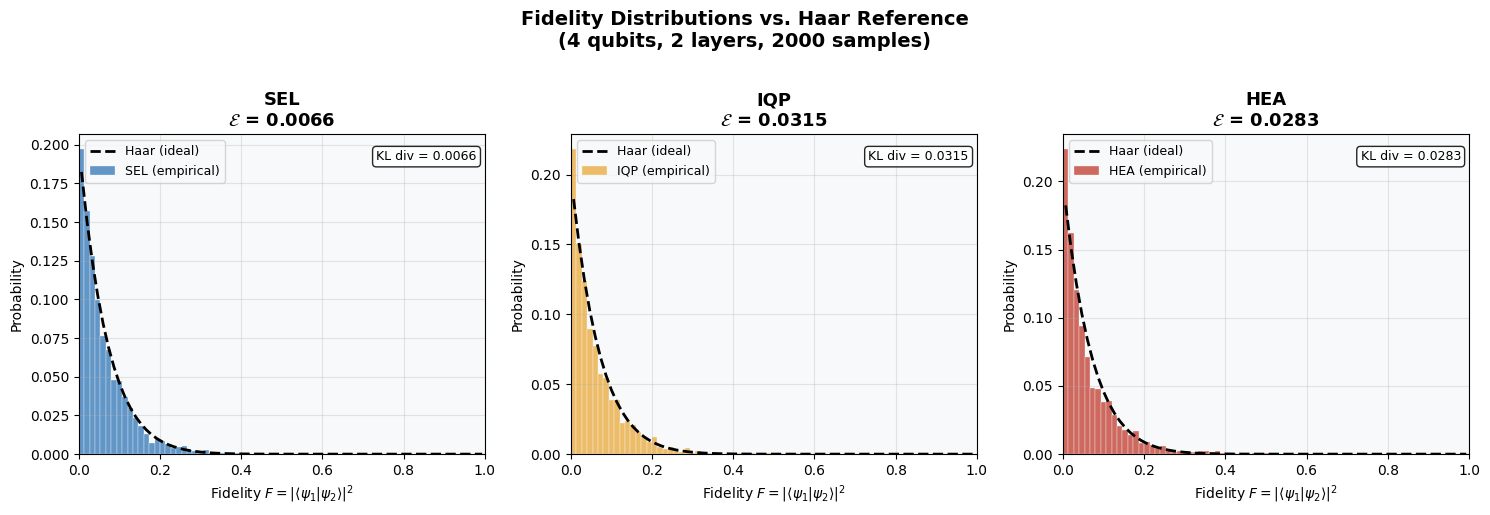

💾 Saved as 'expressibility_distributions.png'


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

colors = {'SEL': '#2E75B6', 'IQP': '#E8A838', 'HEA': '#C0392B'}

for ax, name in zip(axes, ['SEL', 'IQP', 'HEA']):
    r = results[name]

    # Plot empirical fidelity distribution
    ax.bar(r['bin_centers'], r['pqc_probs'],
           width=1/N_BINS, color=colors[name], alpha=0.75,
           label=f'{name} (empirical)', edgecolor='white', linewidth=0.3)

    # Plot Haar reference as a line
    ax.plot(r['bin_centers'], r['haar_probs'],
            color='black', linewidth=2, linestyle='--',
            label='Haar (ideal)')

    ax.set_title(f'{name}\n$\\mathcal{{E}}$ = {r["expressibility"]:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fidelity $F = |\\langle\\psi_1|\\psi_2\\rangle|^2$', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)

    # Annotation: gap from Haar
    ax.text(0.98, 0.95,
            f'KL div = {r["expressibility"]:.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

fig.suptitle(
    f'Fidelity Distributions vs. Haar Reference\n({N_QUBITS} qubits, {N_LAYERS} layers, {N_SAMPLES} samples)',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('expressibility_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'expressibility_distributions.png'")

---

## Cell 6 — Plot: Expressibility Score Comparison (Bar Chart)

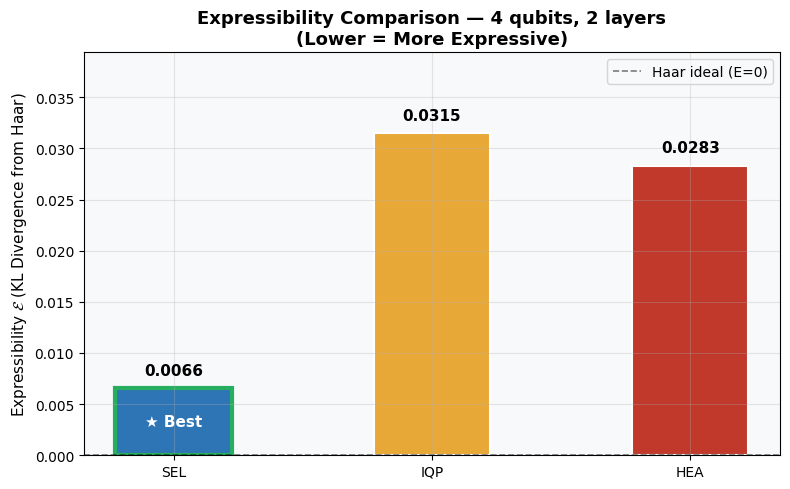

💾 Saved as 'expressibility_comparison.png'


In [7]:
names  = list(results.keys())
scores = [results[n]['expressibility'] for n in names]
colors_list = [colors[n] for n in names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, scores, color=colors_list, width=0.45, edgecolor='white', linewidth=1.5)

# Value labels
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Ideal reference line at 0
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='Haar ideal (E=0)')

ax.set_ylabel('Expressibility $\\mathcal{E}$ (KL Divergence from Haar)', fontsize=11)
ax.set_title(f'Expressibility Comparison — {N_QUBITS} qubits, {N_LAYERS} layers\n(Lower = More Expressive)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(scores) * 1.25)
ax.legend(fontsize=10)

# Highlight best
best_idx = np.argmin(scores)
bars[best_idx].set_edgecolor('#27AE60')
bars[best_idx].set_linewidth(3)
ax.text(best_idx, scores[best_idx] / 2, '★ Best', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('expressibility_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'expressibility_comparison.png'")

---

## Cell 7 — Depth Sweep: Expressibility vs. Number of Layers

**Question:** Does adding more layers always improve expressibility? Or do circuits hit a ceiling?

 **This cell takes ~10–15 minutes.** It runs the expressibility computation for each circuit at depths 1 through 6.

In [8]:
# ── Depth sweep ─────────────────────────────────────────────────────────────
# Reduce samples here to speed up the sweep
N_SAMPLES_SWEEP = 500  # Lower than main experiment for speed

depth_results = {'SEL': [], 'IQP': [], 'HEA': []}
layer_range = range(1, MAX_LAYERS + 1)

for n_layers in layer_range:
    print(f"\n── Layers = {n_layers} ──")

    # SEL
    sel_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=N_QUBITS)

    @qml.qnode(dev_sv)
    def sel_sv_depth(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
        return qml.state()

    expr_sel, *_ = compute_expressibility(sel_sv_depth, sel_shape, N_QUBITS, N_SAMPLES_SWEEP)
    depth_results['SEL'].append(expr_sel)
    print(f"  SEL : {expr_sel:.5f}")

    # IQP
    iqp_shape = (n_layers, N_QUBITS, 2)
    n_lay = n_layers  # capture for closure

    @qml.qnode(dev_sv)
    def iqp_sv_depth(inputs, weights):
        for layer in range(weights.shape[0]):
            for i in range(N_QUBITS):
                qml.RX(inputs[i], wires=i)
                qml.RZ(weights[layer, i, 0], wires=i)
            for i in range(N_QUBITS):
                qml.IsingZZ(weights[layer, i, 1], wires=[i, (i+1) % N_QUBITS])
            for i in range(N_QUBITS):
                qml.Hadamard(wires=i)
        return qml.state()

    expr_iqp, *_ = compute_expressibility(iqp_sv_depth, iqp_shape, N_QUBITS, N_SAMPLES_SWEEP)
    depth_results['IQP'].append(expr_iqp)
    print(f"  IQP : {expr_iqp:.5f}")

    # HEA
    hea_shape = (n_layers, N_QUBITS, 2)

    @qml.qnode(dev_sv)
    def hea_sv_depth(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        for layer in range(weights.shape[0]):
            for i in range(N_QUBITS):
                qml.RY(weights[layer, i, 0], wires=i)
                qml.RZ(weights[layer, i, 1], wires=i)
            for i in range(N_QUBITS - 1):
                qml.CNOT(wires=[i, i+1])
        return qml.state()

    expr_hea, *_ = compute_expressibility(hea_sv_depth, hea_shape, N_QUBITS, N_SAMPLES_SWEEP)
    depth_results['HEA'].append(expr_hea)
    print(f"  HEA : {expr_hea:.5f}")

print("\n✅ Depth sweep complete!")


── Layers = 1 ──
  SEL : 0.34081
  IQP : 23.02585
  HEA : 0.42201

── Layers = 2 ──
  SEL : 0.04445
  IQP : 0.04605
  HEA : 0.05860

── Layers = 3 ──
  SEL : 0.03455
  IQP : 0.03712
  HEA : 0.03640

── Layers = 4 ──
  SEL : 0.03247
  IQP : 0.02427
  HEA : 0.03963

── Layers = 5 ──
  SEL : 0.02620
  IQP : 0.03885
  HEA : 0.02057

── Layers = 6 ──
  SEL : 0.03625
  IQP : 0.02428
  HEA : 0.02550

✅ Depth sweep complete!


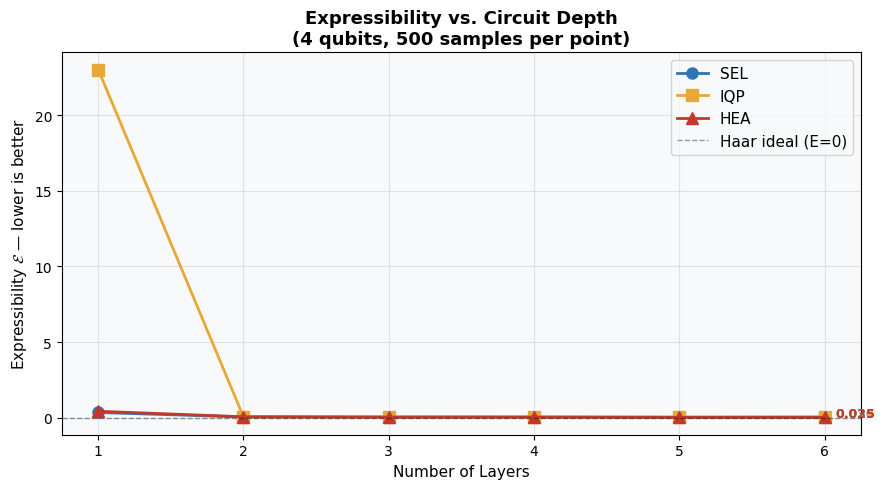

💾 Saved as 'expressibility_vs_depth.png'


In [10]:
# Plot depth sweep
fig, ax = plt.subplots(figsize=(9, 5))

markers = {'SEL': 'o', 'IQP': 's', 'HEA': '^'}
colors_map = {'SEL': '#2E75B6', 'IQP': '#E8A838', 'HEA': '#C0392B'}
layers_x = list(layer_range)

for name in ['SEL', 'IQP', 'HEA']:
    ax.plot(layers_x, depth_results[name],
            color=colors_map[name], marker=markers[name],
            linewidth=2, markersize=8, label=name)

    # Annotate final value
    ax.annotate(f'{depth_results[name][-1]:.3f}',
                xy=(layers_x[-1], depth_results[name][-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=colors_map[name], fontweight='bold')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.4, label='Haar ideal (E=0)')
ax.set_xlabel('Number of Layers', fontsize=11)
ax.set_ylabel('Expressibility $\\mathcal{E}$ (KL Divergence)', fontsize=11)
ax.set_title(f'Expressibility vs. Circuit Depth\n({N_QUBITS} qubits, {N_SAMPLES_SWEEP} samples per point)',
             fontsize=13, fontweight='bold')
ax.set_xticks(layers_x)
ax.legend(fontsize=11)
ax.invert_yaxis()  # Lower = better, so flip for intuitive reading
ax.set_ylabel('Expressibility (↑ = more expressive)', fontsize=11)

# Restore correct orientation
ax.invert_yaxis()
ax.set_ylabel('Expressibility $\\mathcal{E}$ — lower is better', fontsize=11)

plt.tight_layout()
plt.savefig('expressibility_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved as 'expressibility_vs_depth.png'")

---

## Cell 8 — Final Summary & Interpretation

In [11]:
print("=" * 65)
print(f"{'EXPRESSIBILITY ANALYSIS — FULL SUMMARY':^65}")
print(f"Configuration: {N_QUBITS} qubits, {N_LAYERS} layers, {N_SAMPLES} sample pairs")
print("=" * 65)
print(f"{'Circuit':<10} {'Expr. (E)':>12} {'Params':>8} {'E/Param':>12} {'Rank':>6}")
print("-" * 65)

param_counts = {
    'SEL': int(np.prod(qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS))),
    'IQP': N_LAYERS * N_QUBITS * 2,
    'HEA': N_LAYERS * N_QUBITS * 2
}

sorted_by_expr = sorted(results.items(), key=lambda x: x[1]['expressibility'])
for rank, (name, r) in enumerate(sorted_by_expr, 1):
    e = r['expressibility']
    p = param_counts[name]
    print(f"{name:<10} {e:>12.6f} {p:>8} {e/p:>12.6f} {rank:>6}")

print("=" * 65)
print()

best_name = sorted_by_expr[0][0]
best_expr = sorted_by_expr[0][1]['expressibility']
worst_name = sorted_by_expr[-1][0]
worst_expr = sorted_by_expr[-1][1]['expressibility']

print("📌 Key findings:")
print(f"  • {best_name} is the MOST expressive (E={best_expr:.4f}) — closest to Haar-random")
print(f"  • {worst_name} is the LEAST expressive (E={worst_expr:.4f}) — most restricted output space")
print(f"  • Expressibility gap : {worst_expr/best_expr:.1f}x difference between best and worst")
print()
print("📌 Implication for attention layers:")
print(f"  • {best_name} can generate the most diverse attention patterns")
print(f"  • But more expressive ≠ more trainable (see Notebook 03 for barren plateaus)")
print(f"  • E/Param ratio shows parameter efficiency — lower ratio = better use of parameters")
print()
print("➡️  Next: Notebook 03 — Barren Plateau Analysis")

             EXPRESSIBILITY ANALYSIS — FULL SUMMARY              
Configuration: 4 qubits, 2 layers, 2000 sample pairs
Circuit       Expr. (E)   Params      E/Param   Rank
-----------------------------------------------------------------
SEL            0.006580       24     0.000274      1
HEA            0.028309       16     0.001769      2
IQP            0.031525       16     0.001970      3

📌 Key findings:
  • SEL is the MOST expressive (E=0.0066) — closest to Haar-random
  • IQP is the LEAST expressive (E=0.0315) — most restricted output space
  • Expressibility gap : 4.8x difference between best and worst

📌 Implication for attention layers:
  • SEL can generate the most diverse attention patterns
  • But more expressive ≠ more trainable (see Notebook 03 for barren plateaus)
  • E/Param ratio shows parameter efficiency — lower ratio = better use of parameters

➡️  Next: Notebook 03 — Barren Plateau Analysis


In [14]:
# ── Optional: Save to Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import shutil, os
save_dir = '/content/drive/MyDrive/quantum-attention-benchmark/results/'
os.makedirs(save_dir, exist_ok=True)
for fname in ['expressibility_distributions.png','expressibility_comparison.png','expressibility_vs_depth.png']:
     shutil.copy(fname, save_dir)
print(f'✅ Saved to {save_dir}')

print("Notebook 02 complete! ✅")
print()
print("Plots generated:")
print("  ✓ expressibility_distributions.png — fidelity histograms vs Haar")
print("  ✓ expressibility_comparison.png   — bar chart of expressibility scores")
print("  ✓ expressibility_vs_depth.png     — how expressibility changes with depth")

Mounted at /content/drive
✅ Saved to /content/drive/MyDrive/quantum-attention-benchmark/results/
Notebook 02 complete! ✅

Plots generated:
  ✓ expressibility_distributions.png — fidelity histograms vs Haar
  ✓ expressibility_comparison.png   — bar chart of expressibility scores
  ✓ expressibility_vs_depth.png     — how expressibility changes with depth
